# WGCNA
weighted gene co-expression network analysis

using [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)

# Phase 1 

following [Hovrath Lab Tutorial](https://www.dropbox.com/scl/fo/4vqfiysan6rlurfo2pbnk/h?dl=0&e=1&preview=Consensus-NetworkConstruction-man.pdf&rlkey=thqg8wlpdn4spu3ihjuc1kmlu) and [Phase 2 analysis](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/wgcna_p2.ipynb)

In [82]:
packageVersion('WGCNA')

[1] ‘1.73’

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(WGCNA)
library(janitor) # for row_to_names()
library(zoo)
library(ComplexHeatmap)
library(circlize)
library(reshape)
library(fastDummies) # create 0/1 factor columns
library(ape) # for read.gff
library(cowplot) # for plot_grid()
library(grid)

In [3]:
# important setting, cannot omit
options(stringsAsFactors = FALSE)

In [4]:
# allow multi-threading within WGCNA
enableWGCNAThreads()

Allowing parallel execution with up to 191 working processes.


## 1. structure WGCNA input

**Expected input**:
- Rows = samples
- Columns = genes (or probes/features)
- Values = numeric expression values

### A. format vst normalized counts matrix

In [5]:
# counts matrix - sample x gene name
dataExpr <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv') %>%
  t() %>%
  as.data.frame() %>%
  row_to_names(row_number = 1)

# Convert all expression values to numeric
dataExpr <- dataExpr %>%
  mutate(across(everything(), as.numeric))

dim(dataExpr)
head(dataExpr)

[1]    23 25196

,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,11.21797,9.238570,6.162650,9.891478,13.54096,8.717293,6.959982,8.815484,10.82426,8.927974,⋯,10.060202,8.072601,8.973555,8.209398,13.82853,8.183136,11.73396,10.36382,5.806396,7.650699
B2_Nu_O12,11.93477,14.233747,6.596958,10.157309,13.76614,8.463000,6.818915,9.457031,11.02455,8.948950,⋯,8.226926,7.828894,9.248721,9.412852,13.99600,9.081233,12.03657,10.66725,7.454777,6.678052
B4_Nu_O32,11.22476,13.248661,6.709412,10.265604,14.14553,8.350118,7.606161,10.615423,10.82696,9.773306,⋯,10.134694,9.138448,7.740728,9.103312,13.44017,7.646124,12.33896,10.87935,6.200144,6.055887
B5_Nu_O36,11.38600,6.734822,6.097391,9.957131,13.22474,8.954966,6.992122,9.415816,11.47672,8.483401,⋯,9.283546,9.406067,8.660342,8.954966,13.47015,7.307475,12.45764,11.56097,6.217233,6.308727
B6_Nu_O47,11.49149,7.542979,6.365111,10.370479,13.08495,9.308119,7.096395,9.329882,10.70249,9.482208,⋯,9.958212,10.059638,9.016993,8.914578,13.28523,7.012313,12.00298,11.40141,6.087060,7.246549
C1_Nu_W01,11.33041,13.067731,6.642652,10.049745,13.04466,8.469442,7.425683,8.879248,10.54418,9.303008,⋯,10.147132,7.816816,9.348796,9.474347,13.46469,7.409067,11.16733,10.58856,6.881117,7.400669


### B. identify and remove genes with missing data 
genes with too many NAs or zero-counts

In [6]:
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
gsg$allOK

dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
dim(dataExpr) # 23 samples x 28705 genes

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

[1]    23 25196

### C. Sample size and gene filtering

removing low-variance genes first:

In [7]:
dataExpr <- dataExpr[, apply(dataExpr, 2, var) > quantile(apply(dataExpr, 2, var), 0.25)]
dim(dataExpr) # 23 samples x 18897 genes

[1]    23 18897

### D. Sample outlier detection

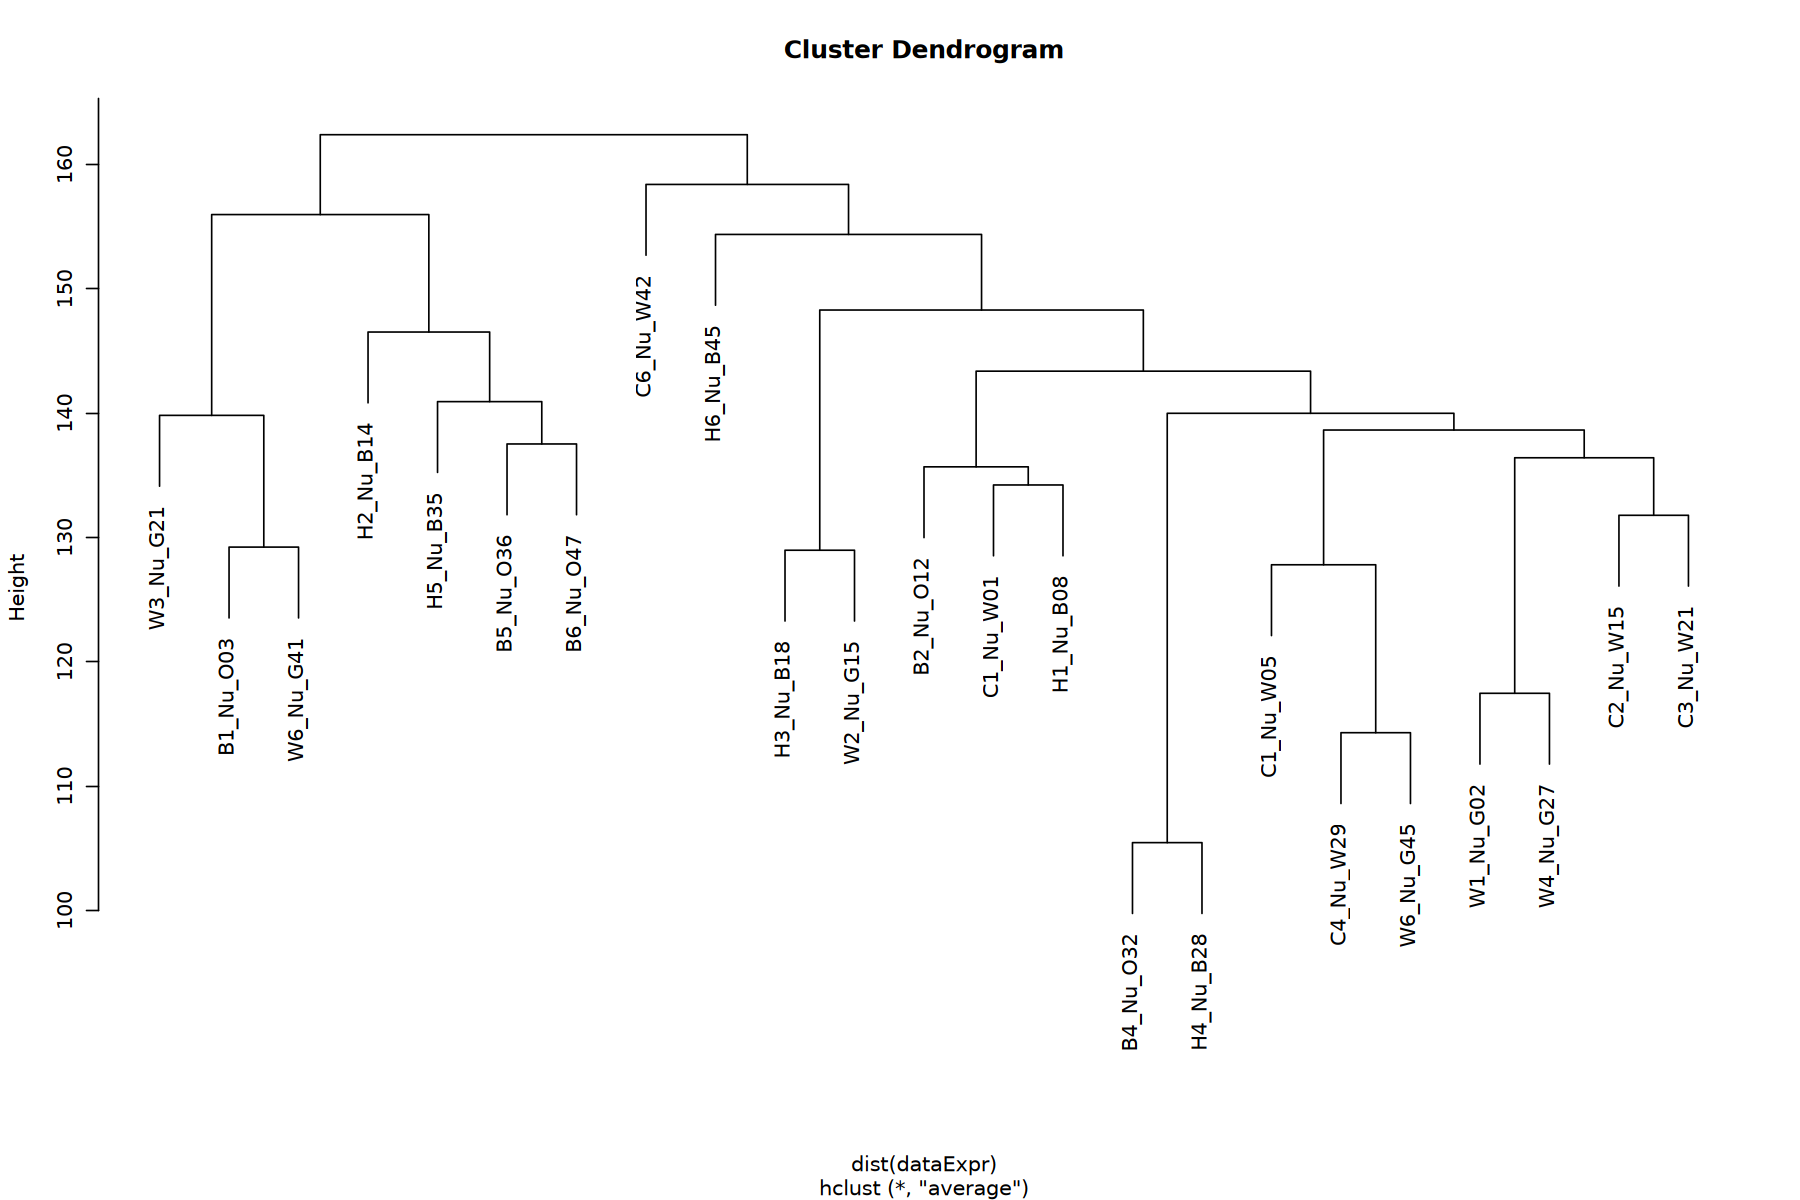

In [8]:
options(repr.plot.width = 15, repr.plot.height = 10)

sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

no obvious outliers

In [9]:
# QC check again
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

### meta data
could add phenotypic data to this ...

In [10]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(grepl("Nu", Sample)) # filter out phase 2 samples - only want phase 1

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

# removing same samples as dataExpr
meta <- meta[rownames(meta) %in% rownames(dataExpr), ]

head(meta)
dim(meta) # 21 samples

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA


[1] 23  8

In [11]:
# double checking the samples in rownames are the same
all(rownames(meta) == rownames(dataExpr))

[1] TRUE

## 2. simple WGCNA network construction and module identification
start with simple, can progress to consensus if deemed necessary

In [12]:
# final QC check
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

In [13]:
#write.csv(colnames(dataExpr), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/outputs/p1.wgcna_UniversalGeneList.csv', row.names = FALSE)

### A. choose soft thresholding power (β)
analysis of network topology

In [14]:
powers <- c(1:20)
sft <- pickSoftThreshold(
  dataExpr,
  powerVector = powers,
  networkType = "signed",
  verbose = 5
)


pickSoftThreshold: will use block size 2367.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 2367 of 18897
   ..working on genes 2368 through 4734 of 18897
   ..working on genes 4735 through 7101 of 18897
   ..working on genes 7102 through 9468 of 18897
   ..working on genes 9469 through 11835 of 18897
   ..working on genes 11836 through 14202 of 18897
   ..working on genes 14203 through 16569 of 18897
   ..working on genes 16570 through 18897 of 18897
   Power SFT.R.sq slope truncated.R.sq mean.k. median.k. max.k.
1      1   0.0840 13.40          0.910  9480.0   9470.00   9960
2      2   0.0223 -2.81          0.711  5060.0   5030.00   5690
3      3   0.3290 -5.56          0.735  2840.0   2800.00   3500
4      4   0.4410 -4.39          0.780  1670.0   1630.00   2330
5      5   0.5250 -3.65          0.813  1030.0    979.00   1670
6      6   0.6670 -3.36          0.870   653.0    608.00   1260
7      7   0.7860 -3.15          0.917   430.0

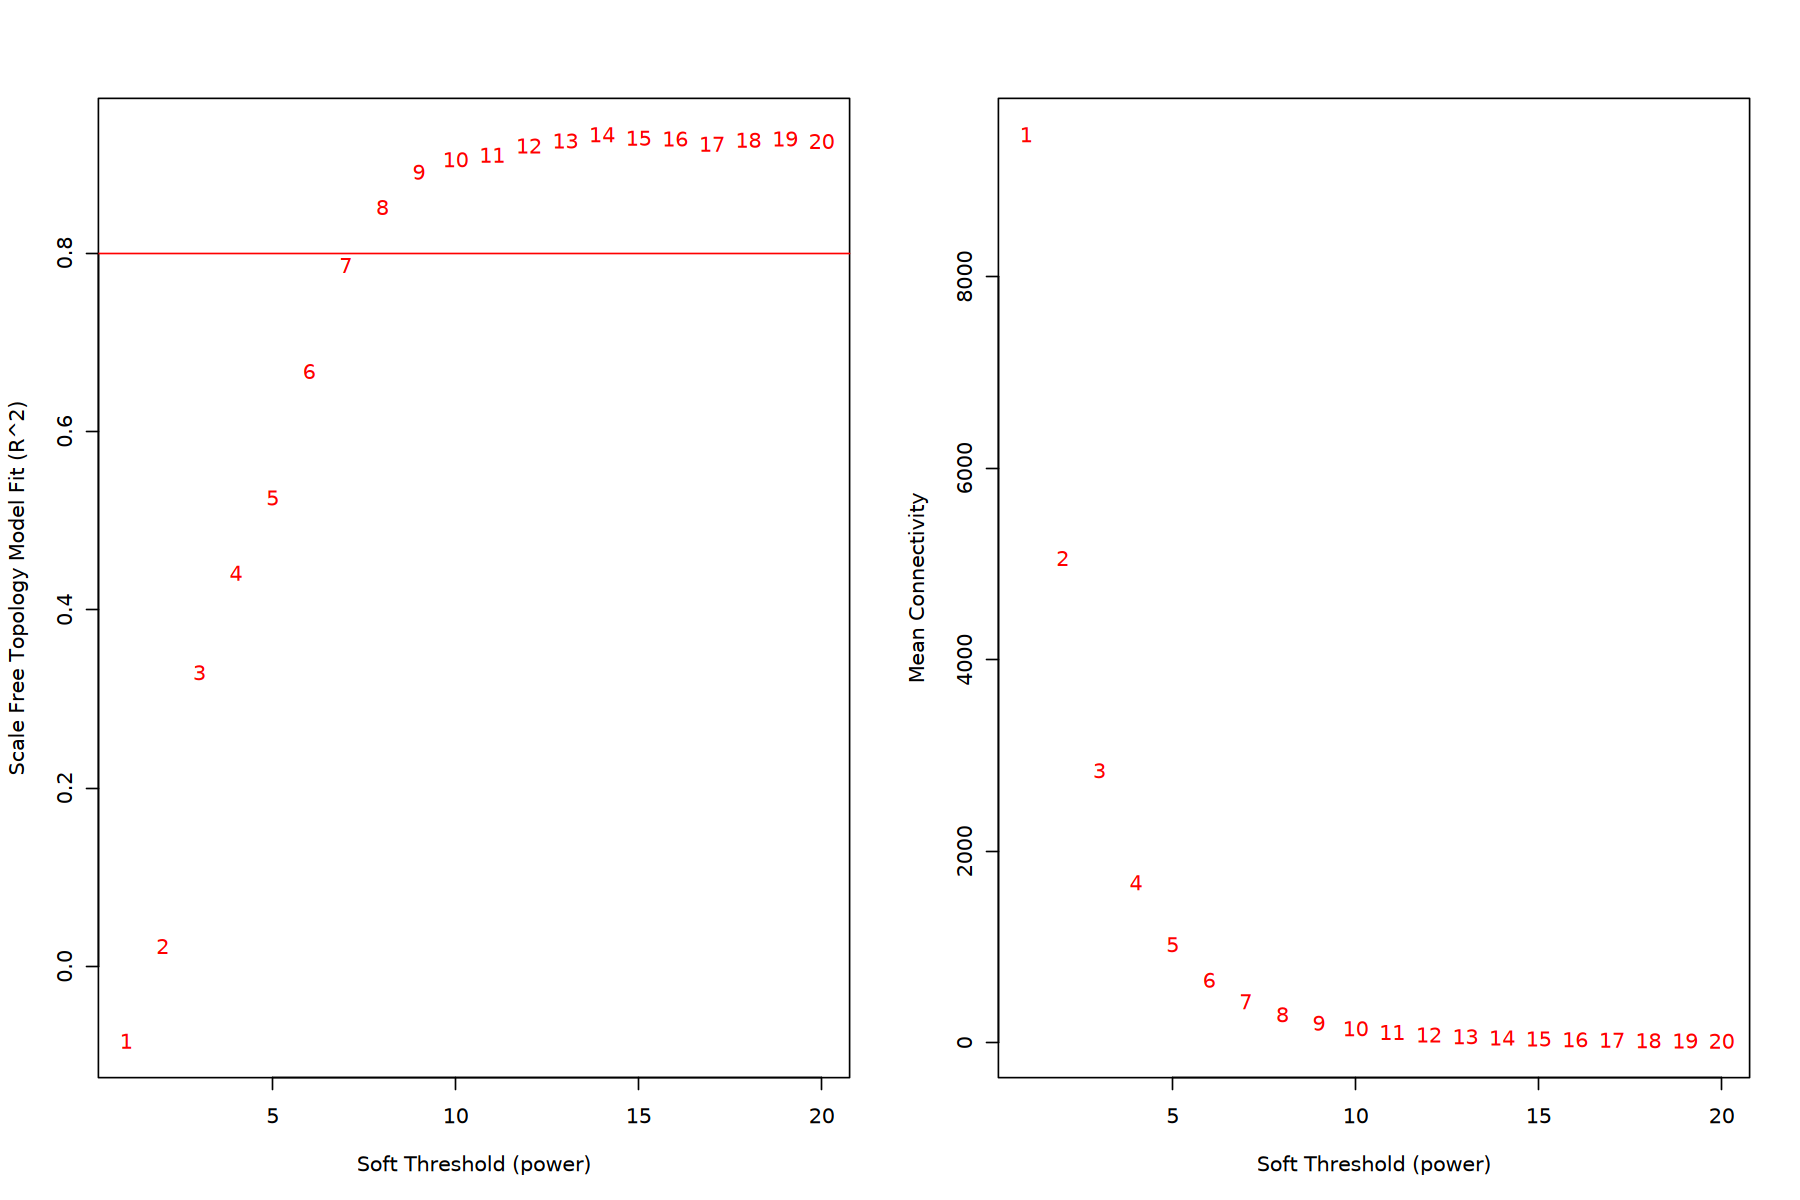

In [15]:
par(mfrow = c(1,2))
plot(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  xlab = "Soft Threshold (power)",
  ylab = "Scale Free Topology Model Fit (R^2)",
  type = "n"
)
text(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  labels = powers,
  col = "red"
)
abline(h = 0.8, col = "red")

plot(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  xlab = "Soft Threshold (power)",
  ylab = "Mean Connectivity",
  type = "n"
)
text(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  labels = powers,
  col = "red"
)


#### left plot - scale-free topology
the red line is where R^2 is 0.8 - you want the lowest power that reaches this - 13 is just above 0.8 and anything after 13 plateaus

#### right plot - mean connectivity
connectivity should not collapse to 0 - by power ~14, the connectivity approaches 0

based on this, I think power of 8 should be appropriate

### B. co-expression similarity and adjacency

creating adjacency matrix

In [16]:
softPower <- 8

calculate co-expression adjacency using soft threshold power of 10

doing signed like the phase 2 vs. phase 2 analysis

In [17]:
# signed
adjacency_sign <- adjacency(dataExpr, power = softPower, type = 'signed') 
head(adjacency_sign)

,LOC144621269,LOC111120925,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,LOC111103567,LOC111103568,⋯,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
LOC144621269,1.000000e+00,0.0161563443,0.0295277316,3.520048e-05,0.024817046,0.003177320,0.0720285617,0.007492639,0.016668857,0.0046891875,⋯,0.0126637830,0.013551057,0.0011176400,0.0183274292,0.0065646340,0.0177350443,0.0030160229,7.038098e-04,0.0730122331,0.0007556756
LOC111120925,1.615634e-02,1.0000000000,0.0100923818,1.778620e-05,0.003163541,0.004292319,0.0272636004,0.001294729,0.001501835,0.0005500491,⋯,0.0069881106,0.001773379,0.0000901909,0.0001142492,0.0269215530,0.0005256062,0.0460449823,2.011751e-04,0.0009726186,0.0069156088
LOC144621276,2.952773e-02,0.0100923818,1.0000000000,1.673452e-04,0.019689258,0.144244897,0.0035766131,0.020815624,0.001562533,0.0050541038,⋯,0.0006985929,0.001056209,0.0005662755,0.0036171593,0.1404510712,0.1726865588,0.0238285977,3.884341e-05,0.0078904201,0.0004371982
LOC111115920,3.520048e-05,0.0000177862,0.0001673452,1.000000e+00,0.002794856,0.013629039,0.0002663278,0.001134066,0.001866498,0.0083049663,⋯,0.0013175917,0.007079808,0.0976688278,0.0091094830,0.0001954372,0.0053161574,0.0004612922,2.085159e-02,0.0023676098,0.0061517535
LOC144621308,2.481705e-02,0.0031635411,0.0196892576,2.794856e-03,1.000000000,0.057383514,0.0332689317,0.010811861,0.015043821,0.0200728959,⋯,0.0003773835,0.025637754,0.0054167050,0.0145084735,0.0360768266,0.0038147299,0.0194702928,6.603720e-03,0.0037136168,0.0001921448
LOC111112629,3.177320e-03,0.0042923191,0.1442448972,1.362904e-02,0.057383514,1.000000000,0.0010178686,0.012773021,0.002047604,0.0026716559,⋯,0.0001291482,0.006951306,0.0066681821,0.0095960146,0.0297640643,0.0531519293,0.0104740843,7.427503e-04,0.0085517904,0.0029322813


In [18]:
#write.csv(data.frame(gene = rownames(adjacency_sign)), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/outputs/p1.wgcna_UniversalGeneList.csv', row.names = FALSE)

### C. Topological Overlap Matrix (TOM)
transform adjacency into TOM to minimize effects of noise and spurious associations - calculate corresponding dissimilarity

In [19]:
## SIGNED
# turn adjacency into topological overlap
TOM_sign <- TOMsimilarity(adjacency_sign)
head(TOM_sign)

# calculate dissimilarity
dissTOM_sign <- 1-TOM_sign
head(dissTOM_sign)

..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


1.000000000,0.034894187,0.069163409,0.004031529,0.052165217,0.02365838,0.069691900,0.048788070,0.040940796,0.023290183,⋯,0.049047195,0.043044925,0.009902070,0.060868304,0.024460367,0.03963406,0.013677213,0.007706449,0.15451794,0.008825622
0.034894187,1.000000000,0.026459131,0.002752574,0.019065286,0.01842402,0.047420327,0.014617758,0.019318747,0.016915519,⋯,0.023876568,0.016328055,0.003294198,0.007317805,0.036355483,0.00724702,0.055949219,0.010111976,0.01162560,0.024908453
0.069163409,0.026459131,1.000000000,0.004890408,0.029695665,0.05380077,0.014973216,0.021075360,0.009434430,0.013181592,⋯,0.010244077,0.008672332,0.016247061,0.019804500,0.071331348,0.08707101,0.019267341,0.002492105,0.02459407,0.009751289
0.004031529,0.002752574,0.004890408,1.000000000,0.008662224,0.01268500,0.005639833,0.007796998,0.008344634,0.011464050,⋯,0.010628162,0.016634924,0.037171114,0.016203505,0.004262965,0.01627979,0.007332606,0.038174419,0.01005957,0.014355635
0.052165217,0.019065286,0.029695665,0.008662224,1.000000000,0.01988834,0.030404384,0.010204030,0.016932471,0.013836858,⋯,0.006657538,0.017200499,0.022986098,0.014411923,0.030360904,0.03115450,0.025837649,0.014265052,0.01490217,0.007619835
0.023658383,0.018424015,0.053800775,0.012685001,0.019888337,1.00000000,0.009113590,0.009872106,0.006001459,0.006850983,⋯,0.005909843,0.009513466,0.025838139,0.013023657,0.030912988,0.05864943,0.014981094,0.006280243,0.01539547,0.008709121


0.0000000,0.9651058,0.9308366,0.9959685,0.9478348,0.9763416,0.9303081,0.9512119,0.9590592,0.9767098,⋯,0.9509528,0.9569551,0.9900979,0.9391317,0.9755396,0.9603659,0.9863228,0.9922936,0.8454821,0.9911744
0.9651058,0.0000000,0.9735409,0.9972474,0.9809347,0.9815760,0.9525797,0.9853822,0.9806813,0.9830845,⋯,0.9761234,0.9836719,0.9967058,0.9926822,0.9636445,0.9927530,0.9440508,0.9898880,0.9883744,0.9750915
0.9308366,0.9735409,0.0000000,0.9951096,0.9703043,0.9461992,0.9850268,0.9789246,0.9905656,0.9868184,⋯,0.9897559,0.9913277,0.9837529,0.9801955,0.9286687,0.9129290,0.9807327,0.9975079,0.9754059,0.9902487
0.9959685,0.9972474,0.9951096,0.0000000,0.9913378,0.9873150,0.9943602,0.9922030,0.9916554,0.9885359,⋯,0.9893718,0.9833651,0.9628289,0.9837965,0.9957370,0.9837202,0.9926674,0.9618256,0.9899404,0.9856444
0.9478348,0.9809347,0.9703043,0.9913378,0.0000000,0.9801117,0.9695956,0.9897960,0.9830675,0.9861631,⋯,0.9933425,0.9827995,0.9770139,0.9855881,0.9696391,0.9688455,0.9741624,0.9857349,0.9850978,0.9923802
0.9763416,0.9815760,0.9461992,0.9873150,0.9801117,0.0000000,0.9908864,0.9901279,0.9939985,0.9931490,⋯,0.9940902,0.9904865,0.9741619,0.9869763,0.9690870,0.9413506,0.9850189,0.9937198,0.9846045,0.9912909


### D. Call the hierarchical clustering function - plot the tree
hierarchical clustering tree (dendrogram) of genes

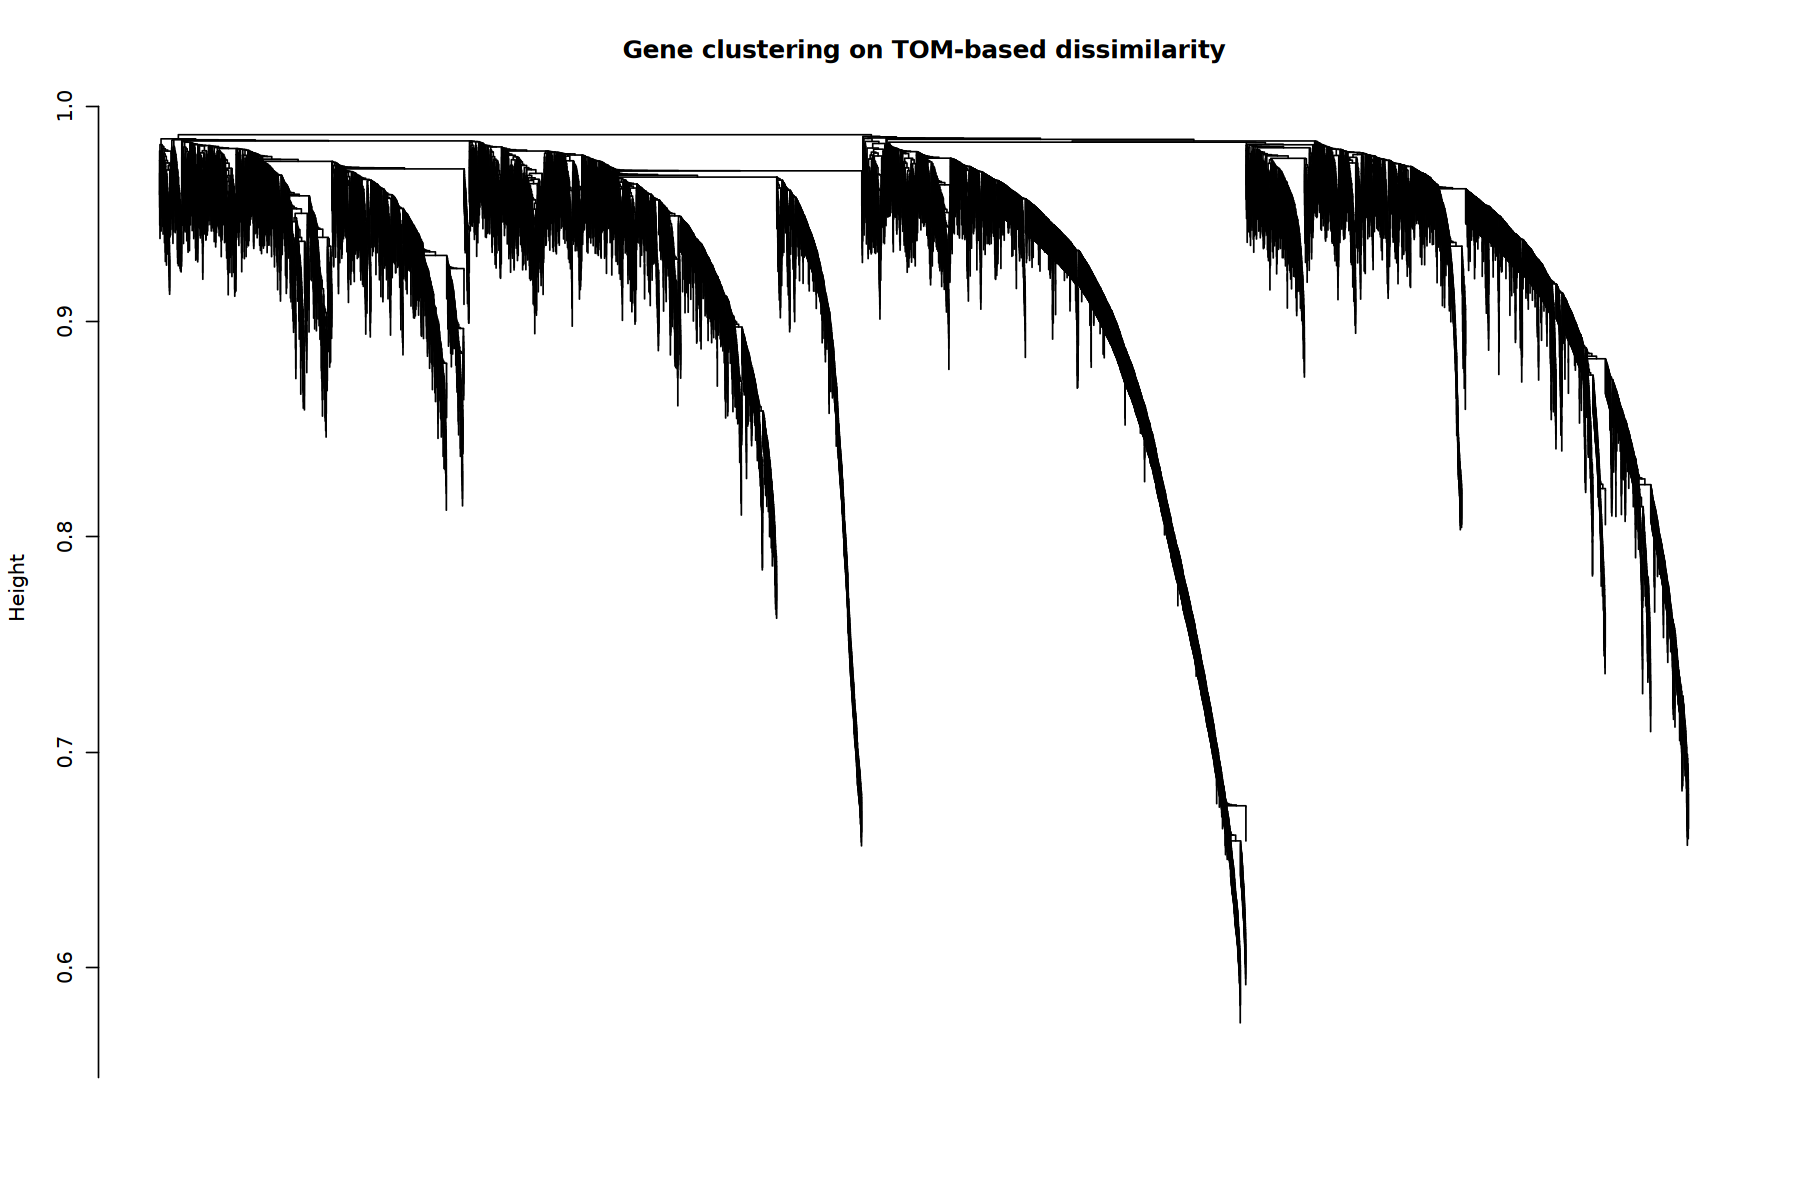

In [20]:
# call hierarchical clustering function
geneTree_sign = hclust(as.dist(dissTOM_sign), method = "average")

# plot the dendrogram
plot(geneTree_sign, xlab="", sub="", main = "Gene clustering on TOM-based dissimilarity",labels = FALSE, hang = 0.04)

each leaf (short vertical line) corresponds to a gene - branches group together densely interconnected, highly co-expressed genes

module identification = cutting branches off the dendrogram

### E. module identification

set minimum module size - this is the smallest number of genes allowed to be put into a module 

then use Dynamic Tree Cut which is the default method for branch cutting and module detection

In [21]:
# would like large modules, so we set the minimum module size relatively high:
minModuleSize <- 100

## SIGNED
# Module identification using dynamic tree cut:
dynamicMods_sign <- cutreeDynamic(dendro = geneTree_sign, distM = dissTOM_sign, 
                             deepSplit = 2, pamRespectsDendro = FALSE,
                             minClusterSize = minModuleSize)
table(dynamicMods_sign) # number of genes per module

 ..cutHeight not given, setting it to 0.984  ===>  99% of the (truncated) height range in dendro.
 ..done.


dynamicMods_sign
   1    2    3    4    5    6    7    8    9   10   11   12 
4554 2632 2367 1904 1837 1678 1467  858  498  399  368  335 

11 modules generated

convert numeric network to colors and plots dendrogram:

dynamicColors_sign
      black        blue       brown       green greenyellow     magenta 
       1467        2632        2367        1837         368         498 
       pink      purple         red         tan   turquoise      yellow 
        858         399        1678         335        4554        1904 

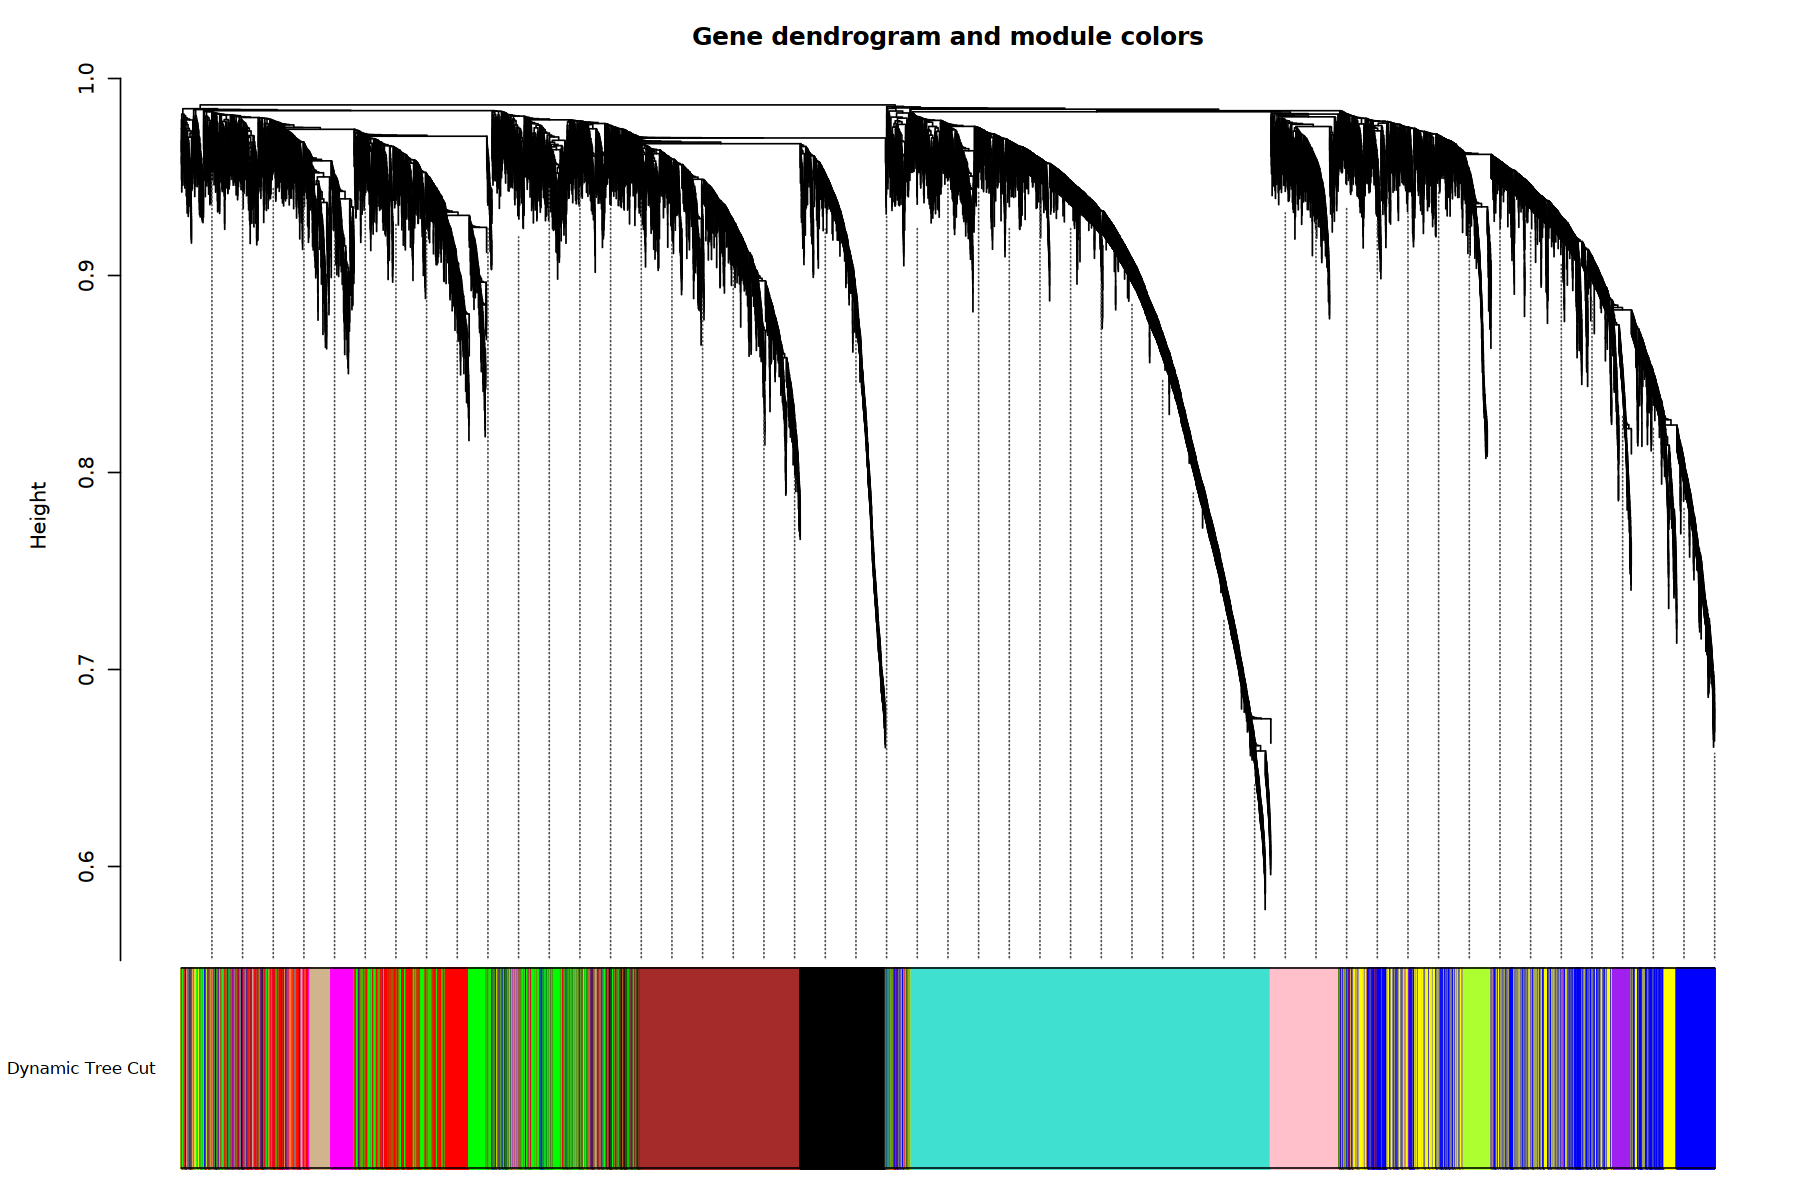

In [22]:
## SIGNED
# Convert numeric lables into colors
dynamicColors_sign <- labels2colors(dynamicMods_sign)
table(dynamicColors_sign)

# Plot the dendrogram and colors underneath
plotDendroAndColors(geneTree_sign, dynamicColors_sign, "Dynamic Tree Cut",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Gene dendrogram and module colors")


### F. merging modules whose GE profiles are similar

this is based on eigengenes, which is the first principal component of a given a gene expression matrix/module that acts as a representative summary profile for a gene module or cluster

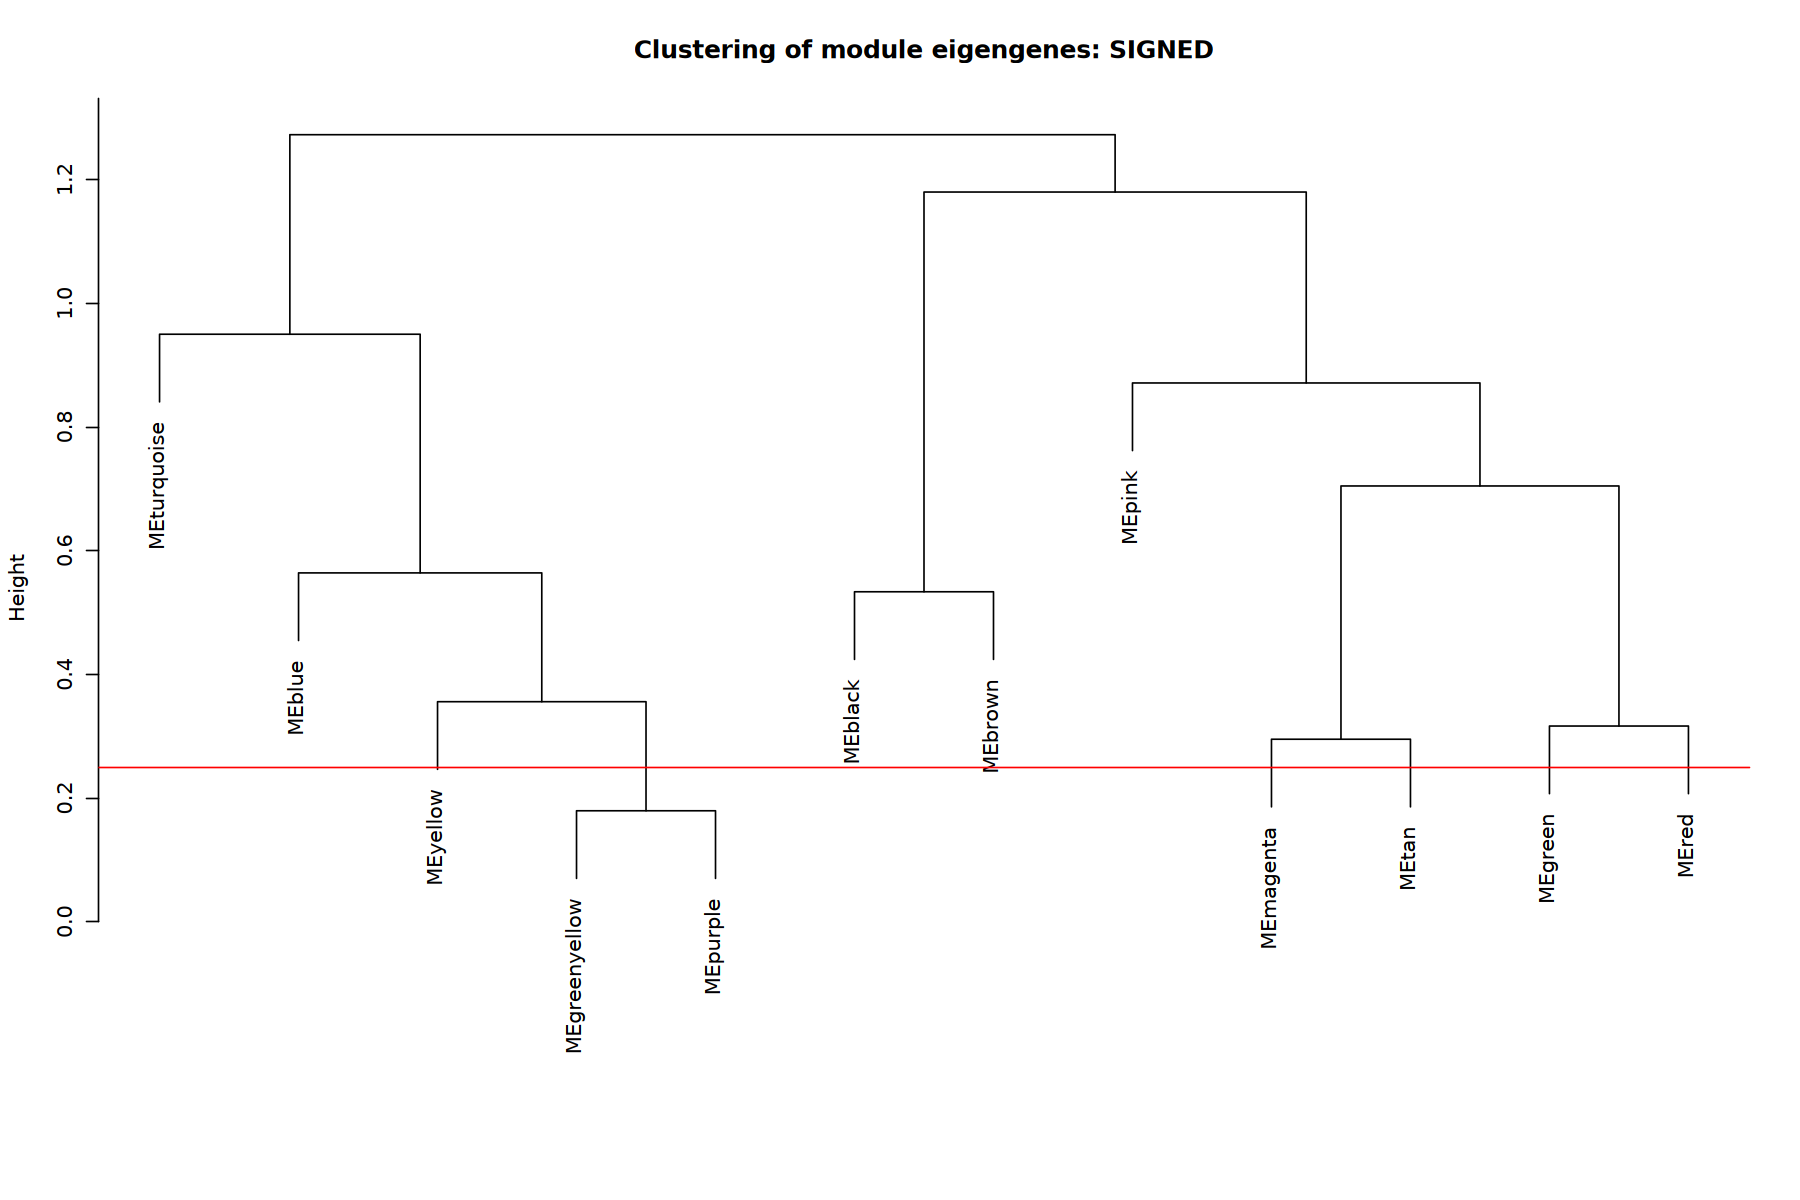

In [23]:
## SIGNED
# Calculate eigengenes
MEList_sign <- moduleEigengenes(dataExpr, colors = dynamicColors_sign)
MEs_sign <- MEList_sign$eigengenes

# Calculate dissimilarity of module eigengenes
MEDiss_sign <- 1-cor(MEs_sign)

# Cluster module eigengenes
METree_sign <- hclust(as.dist(MEDiss_sign), method = "average")

# Plot the result

# height cutoff of 0.25 - corresponds to a correlation of 0.75 to merge
MEDissThres <- 0.25

# Plot the cut line into the dendrogram
plot(METree_sign, main = "Clustering of module eigengenes: SIGNED", xlab = "", sub = "")
abline(h=MEDissThres, col = "red")

any branch with more than 75% correlation are related and will be merged - so blue and purple modules will be merged

 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 12 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 11 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 11 module eigengenes in given set.


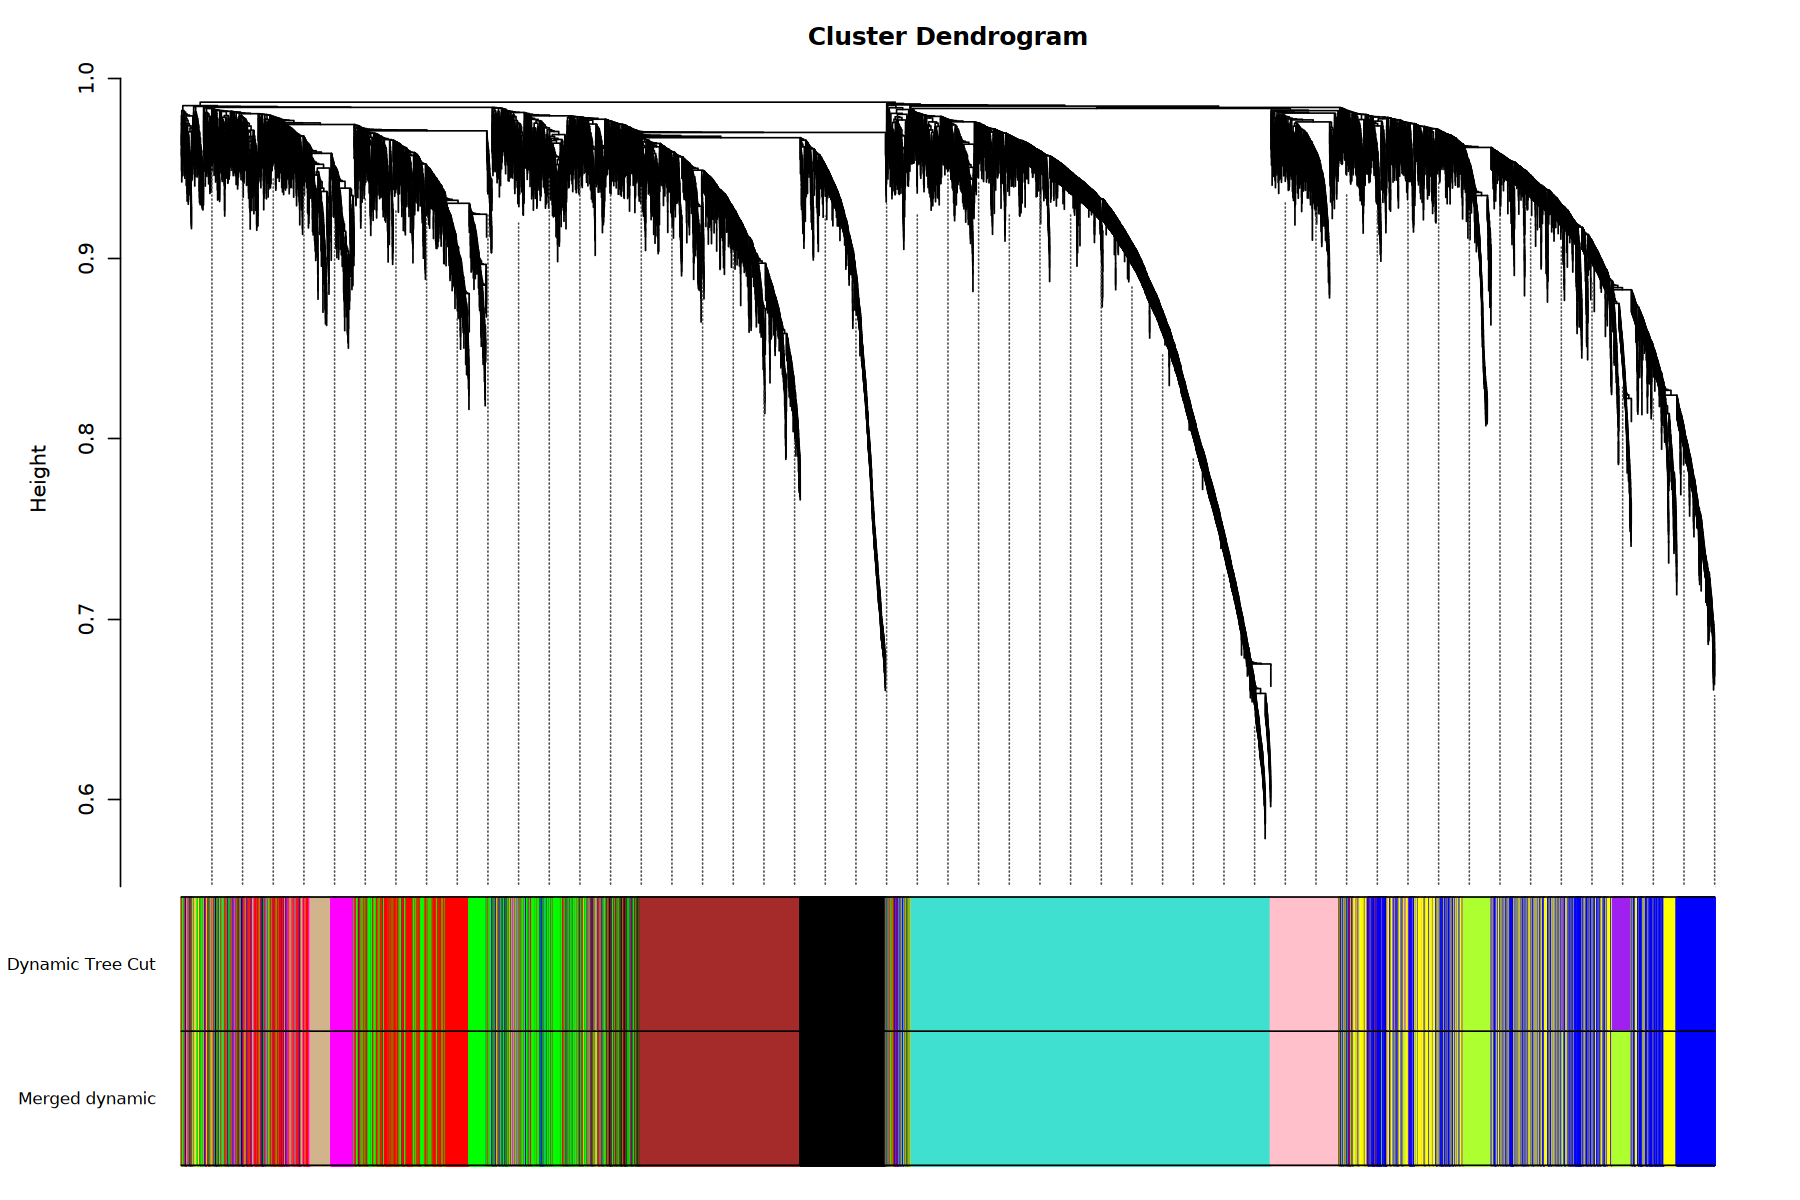

In [24]:
## SIGNED
# Call an automatic merging function
merge_sign <- mergeCloseModules(dataExpr, dynamicColors_sign, cutHeight = MEDissThres, verbose = 3)

# The merged module colors
mergedColors_sign <- merge_sign$colors

# Eigengenes of the new merged modules:
mergedMEs_sign <- merge_sign$newMEs

# plot merged module colors
plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign), 
                    c("Dynamic Tree Cut", "Merged dynamic"),
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)

In [25]:
table(mergedColors_sign)

mergedColors_sign
      black        blue       brown       green greenyellow     magenta 
       1467        2632        2367        1837         767         498 
       pink         red         tan   turquoise      yellow 
        858        1678         335        4554        1904 

11 modules ranging from 335 - 4554 genes

In [26]:
# Recalculate MEs (module eigengenes) with color labels

MEs0 <- moduleEigengenes(dataExpr, mergedColors_sign)$eigengenes # create module eigengenes

MEs <- orderMEs(MEs0) # order so more similar modules are closer together
head(MEs)

,MEturquoise,MEblue,MEgreenyellow,MEyellow,MEblack,MEbrown,MEpink,MEmagenta,MEtan,MEgreen,MEred
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,-0.27982387,0.23258719,0.07083711,0.214094738,-0.13415167,-0.11961069,-0.0260685743,0.069324334,0.078653302,-0.1296516,-0.088950578
B2_Nu_O12,0.26066812,0.05311107,0.29095663,0.110958197,-0.15823494,-0.17412980,-0.0170497653,-0.065874042,0.007717028,-0.2596479,-0.070301932
B4_Nu_O32,0.13987997,-0.25016720,0.11764132,0.004739407,-0.09911141,0.09417070,0.6651687652,-0.043614951,-0.147227006,-0.0136979,-0.031590106
B5_Nu_O36,-0.29840124,-0.17652602,-0.30367854,-0.279517872,-0.13599942,0.31510430,-0.0384361401,0.269477089,-0.013372370,0.3309716,0.298534632
B6_Nu_O47,-0.25845679,-0.08518001,-0.21333867,-0.112692739,-0.12866398,0.01665312,-0.0007297193,0.197555296,0.192558431,0.3297541,0.438028662
C1_Nu_W01,0.07930803,0.36783367,-0.08552084,0.143783737,-0.17391143,-0.26844132,-0.0927382451,0.006135095,0.218249393,-0.1703255,-0.005392966


In [27]:
write.csv(MEs, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_ModuleEigengenes.csv')

## 3. quantifying module-trait associations
identify modules that are significantly associated with treatment exposures or measured traits (like growth)

### A. read in and format metadata

#### treatment data

In [31]:
# read in phase info
dataMeta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')

# keep only samples seen in dataExpr
dataMeta <- dataMeta[dataMeta$Sample %in% rownames(dataExpr),] 

# set sample as rownames
rownames(dataMeta) <- dataMeta$Sample

# check it out
dim(dataMeta)
head(dataMeta)

[1] 23  9

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA


In [32]:
# set factors
dataMeta$Phase1_treatment <- factor(dataMeta$Phase1_treatment, c('control', 'warm', 'hypoxic', 'both'))
dataMeta$Phase1_temp <- factor(dataMeta$Phase1_temp, c('ambient', 'warm'))
dataMeta$Phase1_DO <- factor(dataMeta$Phase1_DO, c('normoxic', 'hypoxic'))

# convert categorical to numerical code for treatment info
### PHASE 1
dataMeta$P1_trtmt_code <- as.numeric(factor(dataMeta$Phase1_treatment))
dataMeta$P1_temp_code <- as.numeric(factor(dataMeta$Phase1_temp))
dataMeta$P1_DO_code <- as.numeric(factor(dataMeta$Phase1_DO))

# select only columns needed
metaData <- dataMeta[,-c(2:9)]

# set sample names as rownames
rownames(metaData) <- metaData$Sample
metaData <- metaData %>% select(-Sample)

dim(metaData)
head(metaData)


[1] 23  3

,P1_trtmt_code,P1_temp_code,P1_DO_code
,<dbl>,<dbl>,<dbl>
B1_Nu_O03,4,2,2
B2_Nu_O12,4,2,2
B4_Nu_O32,4,2,2
B5_Nu_O36,4,2,2
B6_Nu_O47,4,2,2
C1_Nu_W01,1,1,1


In [33]:
# creating dummy variables

#### PHASE 1 ####
# phase 1 treatments
phase1.treatments <- dataMeta %>%
  select(Sample, Phase1_treatment) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_treatment,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
column_to_rownames(var = 'Sample')

head(phase1.treatments)

# phase 1 DO
phase1.DO <- dataMeta %>%
  select(Sample, Phase1_DO) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_DO,
    values_from = value,
    values_fill = list(value = 0)
  )%>%
column_to_rownames(var = 'Sample')

# phase 1 temperature
phase1.temp <- dataMeta %>%
  select(Sample, Phase1_temp) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_temp,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
column_to_rownames(var = 'Sample')

,both,control,hypoxic,warm
,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,1,0,0,0
B2_Nu_O12,1,0,0,0
B4_Nu_O32,1,0,0,0
B5_Nu_O36,1,0,0,0
B6_Nu_O47,1,0,0,0
C1_Nu_W01,0,1,0,0


In [34]:
nSamples <- nrow(dataExpr) # 23 samples
nGenes <- ncol(dataExpr) # 18897 genes

In [35]:
nSamples
nGenes

[1] 23

[1] 18897

In [36]:
# module trait correlation

## PHASE 1 ##
# phase 1 treatment
moduleTraitCor_p1 = cor(MEs, phase1.treatments[-1], use = "p")
moduleTraitPvalue_p1 = corPvalueStudent(moduleTraitCor_p1, nSamples)

# phase 1 DO
moduleTraitCor_p1.DO = cor(MEs, phase1.DO[-1], use = "p")
moduleTraitPvalue_p1.DO = corPvalueStudent(moduleTraitCor_p1.DO, nSamples)

# phase 1 temp
moduleTraitCor_p1.temp = cor(MEs, phase1.temp[-1], use = "p")
moduleTraitPvalue_p1.temp = corPvalueStudent(moduleTraitCor_p1.temp, nSamples)


#### growth data

In [37]:
growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')

# add leading zeros to single digit tag num
growth$Tag_num <- sprintf("%02d", growth$Tag_num)

# make sample names same as my convention
p1_str <- str_sub(growth$Phase_1_treat, 1, 1)
growth$Sample <- paste0(p1_str, growth$Phase_1_rep, '_Nu_', growth$Tag_color, growth$Tag_num)
head(growth$Sample)

# pull out growth data for matching samples
growth <- growth[growth$Sample %in% dataMeta$Sample, ]

# check it out
dim(growth) # 91 samples
dim(dataMeta) # 93 samples

[1] "B1_Nu_O01" "B1_Nu_O02" "B1_Nu_O03" "B1_Nu_O04" "B1_Nu_O05" "B1_Nu_O06"

[1] 23 29

[1] 23 12

In [38]:
# select growth columns
growth.df <- growth %>%
select(Sample, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)

# sample is the rowname
rownames(growth.df) <- growth.df$Sample
growth.df <- growth.df %>% select(-Sample)


head(growth.df)

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<dbl>,<dbl>,<chr>
B1_Nu_O03,77.58660,27.91340,0.359770888
B2_Nu_O12,150.42300,80.37700,0.534339828
B4_Nu_O32,145.03944,105.36056,0.726426964
B5_Nu_O36,32.77638,25.22362,0.769566987
B6_Nu_O47,117.80496,-12.30496,-0.104451969
C1_Nu_W01,232.44312,136.95688,0.589205996


#### merge growth and treatment data

In [39]:
head(phase1.treatments)

,both,control,hypoxic,warm
,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,1,0,0,0
B2_Nu_O12,1,0,0,0
B4_Nu_O32,1,0,0,0
B5_Nu_O36,1,0,0,0
B6_Nu_O47,1,0,0,0
C1_Nu_W01,0,1,0,0


In [40]:
# merge dfs
metaData_merge <- merge(growth.df, metaData, by = "row.names") %>%
column_to_rownames(var = 'Row.names')

metaData_merge <- merge(metaData_merge, phase1.treatments, by = "row.names") %>%
column_to_rownames(var = 'Row.names')

metaData_merge

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P1_temp_code,P1_DO_code,both,control,hypoxic,warm
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,77.58660,27.91340,0.359770888,4,2,2,1,0,0,0
B2_Nu_O12,150.42300,80.37700,0.534339828,4,2,2,1,0,0,0
B4_Nu_O32,145.03944,105.36056,0.726426964,4,2,2,1,0,0,0
B5_Nu_O36,32.77638,25.22362,0.769566987,4,2,2,1,0,0,0
B6_Nu_O47,117.80496,-12.30496,-0.104451969,4,2,2,1,0,0,0
C1_Nu_W01,232.44312,136.95688,0.589205996,1,1,1,0,1,0,0
C1_Nu_W05,142.50600,104.89400,0.736067253,1,1,1,0,1,0,0
C2_Nu_W15,132.53058,103.06942,0.777702927,1,1,1,0,1,0,0
C3_Nu_W21,123.50520,61.49480,0.497912638,1,1,1,0,1,0,0


### B. plot heatmaps

In [48]:
# Recalculate MEs (module eigengenes) with color labels

MEs0 <- moduleEigengenes(dataExpr, mergedColors_sign)$eigengenes # create module eigengenes

MEs <- orderMEs(MEs0) # order so more similar modules are closer together

moduleTraitCor <- cor(MEs, metaData_merge, use = "p") # correlate with traits - using Pearson correlations

moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples) # compute p-values - uses student's t-distribution

#### all traits

In [49]:
# convert correlation matrix to df
cor.df <- as.data.frame(moduleTraitCor) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'Cor')

head(cor.df)

module,Trait,Cor
<chr>,<chr>,<dbl>
MEturquoise,Actual_shell_growth_mg,0.12353843
MEturquoise,Actual_tissue_growth_mg,0.17966721
MEturquoise,Ratio_tissue_shell_mg,0.21460894
MEturquoise,P1_trtmt_code,-0.05082404
MEturquoise,P1_temp_code,-0.29348119
MEturquoise,P1_DO_code,0.09096030


In [50]:
# convert pvalue matrix to df
pval.df <- as.data.frame(moduleTraitPvalue) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'pvalue')

head(pval.df)

module,Trait,pvalue
<chr>,<chr>,<dbl>
MEturquoise,Actual_shell_growth_mg,0.5743967
MEturquoise,Actual_tissue_growth_mg,0.4120399
MEturquoise,Ratio_tissue_shell_mg,0.3254339
MEturquoise,P1_trtmt_code,0.8178592
MEturquoise,P1_temp_code,0.1740994
MEturquoise,P1_DO_code,0.6797819


In [51]:
# merge the two dfs
module.df <- cor.df %>%
left_join(pval.df, by = c('module', 'Trait')) %>%
# add vol to denote significance for bold labeling
mutate(
    label = sprintf("%.2f\n(%.1g)", Cor, pvalue),
    sig = !is.na(pvalue) & pvalue < 0.05
  )

module.df <- module.df %>%
  mutate(
    Trait = factor(Trait, levels = sort(unique(Trait))),
    module = factor(module, levels = sort(unique(module)))
  )

head(module.df)

module,Trait,Cor,pvalue,label,sig
<fct>,<fct>,<dbl>,<dbl>,<chr>,<lgl>
MEturquoise,Actual_shell_growth_mg,0.12353843,0.5743967,0.12 (0.6),FALSE
MEturquoise,Actual_tissue_growth_mg,0.17966721,0.4120399,0.18 (0.4),FALSE
MEturquoise,Ratio_tissue_shell_mg,0.21460894,0.3254339,0.21 (0.3),FALSE
MEturquoise,P1_trtmt_code,-0.05082404,0.8178592,-0.05 (0.8),FALSE
MEturquoise,P1_temp_code,-0.29348119,0.1740994,-0.29 (0.2),FALSE
MEturquoise,P1_DO_code,0.09096030,0.6797819,0.09 (0.7),FALSE


In [52]:
unique(module.df$Trait)

[1] Actual_shell_growth_mg  Actual_tissue_growth_mg Ratio_tissue_shell_mg  
 [4] P1_trtmt_code           P1_temp_code            P1_DO_code             
 [7] both                    control                 hypoxic                
[10] warm                   
10 Levels: Actual_shell_growth_mg Actual_tissue_growth_mg both ... warm

In [53]:
df.clean <- module.df %>%
filter(Trait != 'P1_trtmt_code') %>% # remove treatment interaction
  mutate(Trait = case_match(Trait,
                           "Actual_shell_growth_mg" ~ "Shell Growth",
                           "Actual_tissue_growth_mg" ~ "Tissue Growth",
                            "Ratio_tissue_shell_mg" ~ "Tissue:Shell Growth",
                            "P1_temp_code" ~ "Phase 1 Temp",
                            "P1_DO_code" ~ "Phase 1 DO",
                            "both" ~ "Both",
                            "control" ~ "Control",
                            "hypoxic" ~ "Hypoxic",
                            "warm" ~ "Warm")) %>% # Keeps unchanged values as they are
# add col that denotes if the trait is for treatment or growth data
mutate(
  trait_type = case_when(
    grepl("Growth", Trait) ~ "Growth Data",
    !grepl("Growth|Phase", Trait) ~ "Binary Treatment",
    TRUE ~ "Treatment"
  )
)

head(df.clean)

module,Trait,Cor,pvalue,label,sig,trait_type
<fct>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
MEturquoise,Shell Growth,0.1235384,0.5743967,0.12 (0.6),FALSE,Growth Data
MEturquoise,Tissue Growth,0.1796672,0.4120399,0.18 (0.4),FALSE,Growth Data
MEturquoise,Tissue:Shell Growth,0.2146089,0.3254339,0.21 (0.3),FALSE,Growth Data
MEturquoise,Phase 1 Temp,-0.2934812,0.1740994,-0.29 (0.2),FALSE,Treatment
MEturquoise,Phase 1 DO,0.0909603,0.6797819,0.09 (0.7),FALSE,Treatment
MEturquoise,Both,-0.2204766,0.3120582,-0.22 (0.3),FALSE,Binary Treatment


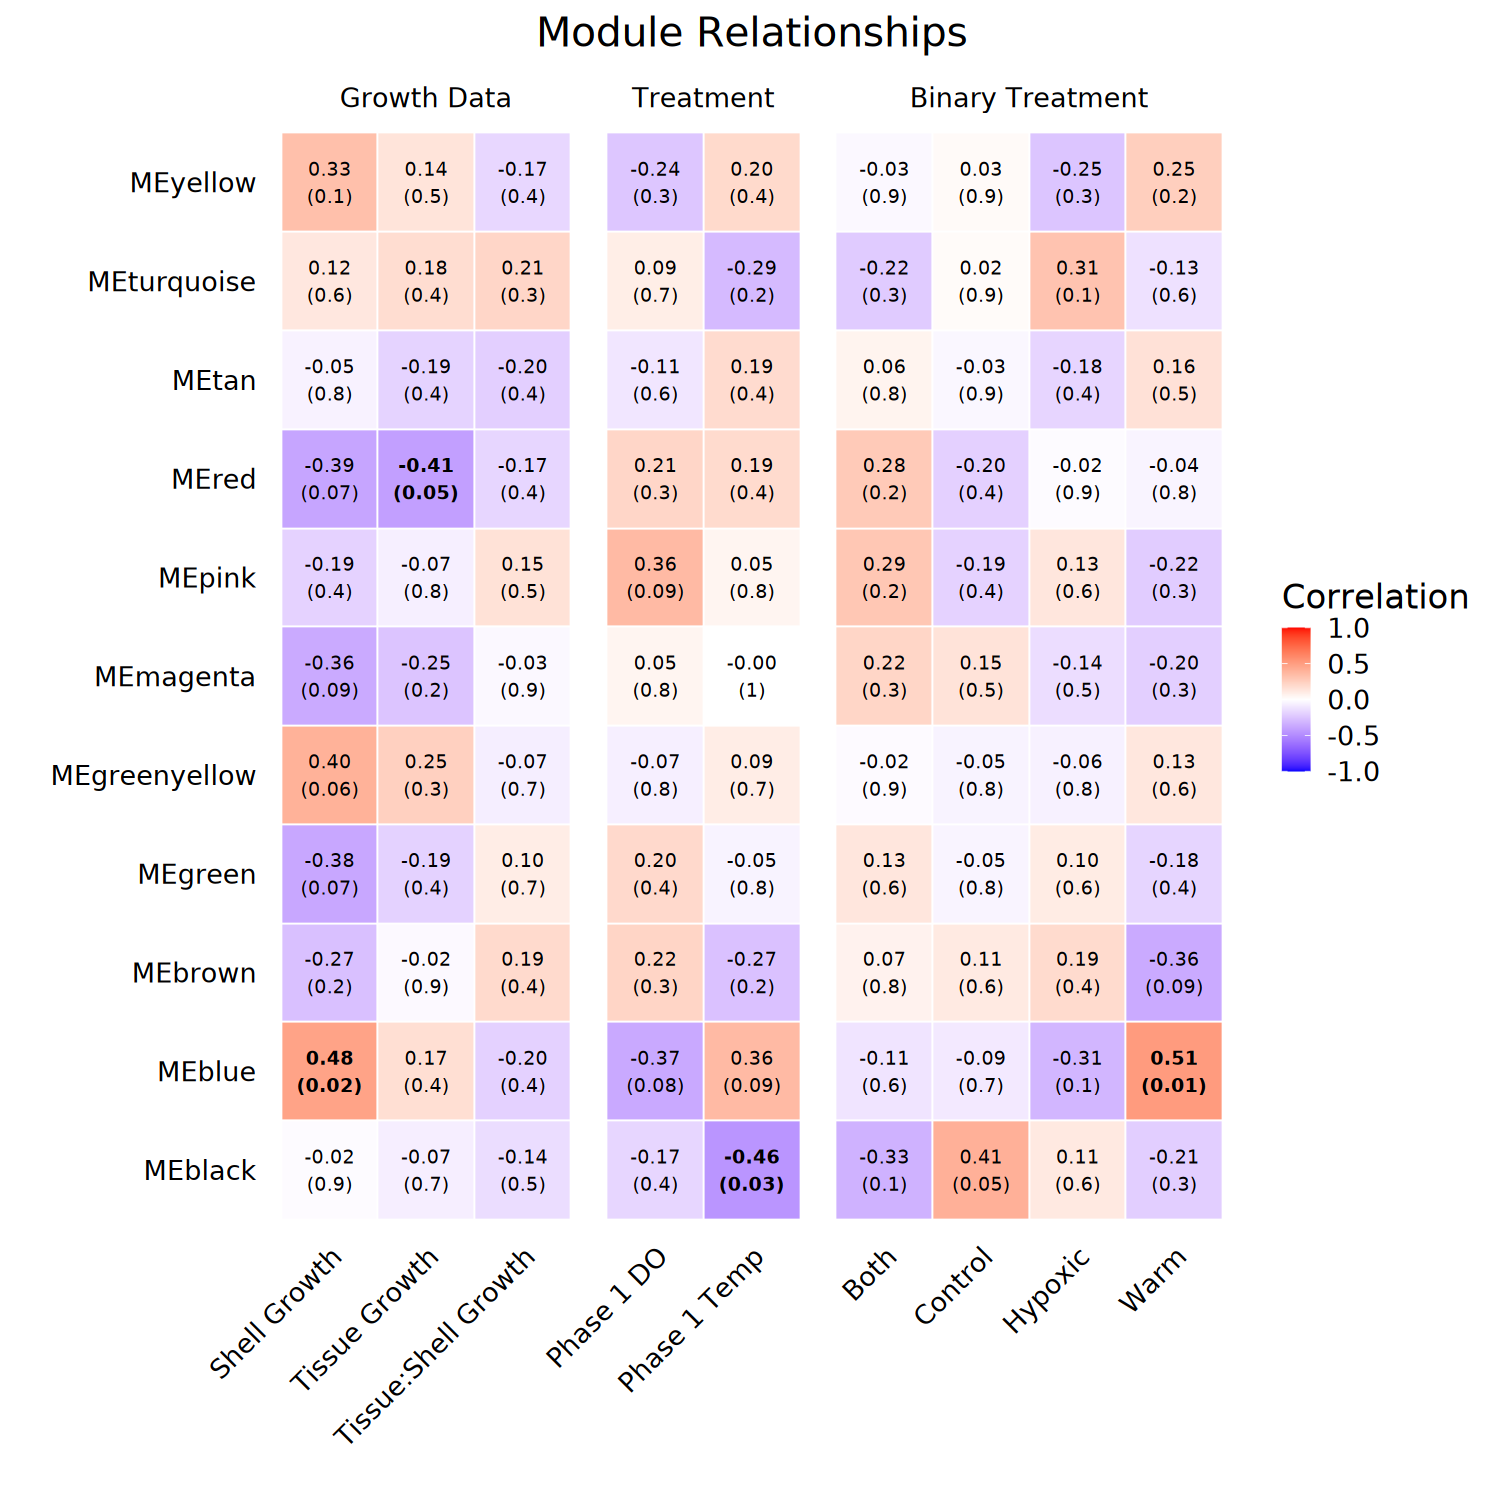

In [54]:
options(repr.plot.width = 12.5, repr.plot.height = 12.5)

facet_order <- c("Growth Data", "Treatment", "Binary Treatment")

df.clean$trait_type <- factor(
  df.clean$trait_type,
  levels = facet_order
)

#

heatmap1 <- ggplot(df.clean, aes(x = Trait, y = module, fill = Cor)) +
  geom_tile(color = "white") +
  
  # text annotations
  geom_text(
    aes(
      label = label,
      fontface = ifelse(sig, "bold", "plain")
    ),
    size = 4
  ) +
  
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    limits = c(-1, 1)
  ) +

  facet_grid(
    ~ trait_type,
    scales = "free_x",
    space = "free_x"
  ) +

  theme_minimal(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = 'black'),
      axis.text.y = element_text(color = 'black'),
    panel.grid = element_blank(),
      plot.title = element_text(hjust = .5),
      strip.text = element_text(color = 'black')
  ) +
  
  labs(
    title = "Module Relationships",
    x = "",
    y = "",
    fill = "Correlation"
  )

heatmap1

**observations**;
- there's no significantly correlated modules with treatment traits, but a lot of stronly correlated modules with growth-related traits
- lightyellow, greenyellow, and cyan are positively correlated with shell growth (so increased growth is correlated with higher expression in this module)
- green is negatively correlated with shell growth (decreased growth ~ lower expression)
-  black is negatively correlated with the tissue:shell growth ratio (so increased T:S ratio (which indicates more tissue than shell i.e., investment in reproduction) is correlated with decreased expression in this module)

## MEs boxplots by treatment group

inspo for this comes from [Gurr's code](https://github.com/SamGurr/Pgenerosa_OA_TagSeq/blob/main/TagSeq/Analysis/Scripts/Day21_WGCNA_all.R) - plotting every module's ME (module eigengene) for each treatment combination - this will allow me to take a closer look at the relationship between modules and phase 1 and 2 treatments


then create df to plot boxplots - want the metadata and module eigengene info in long format

In [55]:
# Create ME table
MEs_df <- as.data.frame(MEs)
MEs_df$Sample <- rownames(MEs_df)

# format metadata and merge with MEs
dataMeta2 <- dataMeta[,1:4]
dim(dataMeta2)

# merge MEs and metadata
MEsPlotting <- merge(dataMeta2, MEs_df, by = 'Sample')

# Melt to long format
MEsPlotting_melt <- reshape2::melt(
  MEsPlotting,
  id.vars = c("Sample",
              "Phase1_treatment",
              "Phase1_temp",
              "Phase1_DO"
             ),
  variable.name = "Module",
  value.name = "Eigengene"
)

MEsPlotting_melt <- MEsPlotting_melt %>%
filter(!grepl('code', Module)) # remove treatment code rows

head(MEsPlotting_melt)

[1] 23  4

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Module,Eigengene
,<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>
1,B1_Nu_O03,both,warm,hypoxic,MEturquoise,-0.27982387
2,B2_Nu_O12,both,warm,hypoxic,MEturquoise,0.26066812
3,B4_Nu_O32,both,warm,hypoxic,MEturquoise,0.13987997
4,B5_Nu_O36,both,warm,hypoxic,MEturquoise,-0.29840124
5,B6_Nu_O47,both,warm,hypoxic,MEturquoise,-0.25845679
6,C1_Nu_W01,control,ambient,normoxic,MEturquoise,0.07930803


In [53]:
# save metadata in case I skip code above
#write.csv(MEsPlotting_melt, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p2.wgcna_metadata.csv')

make boxplot!

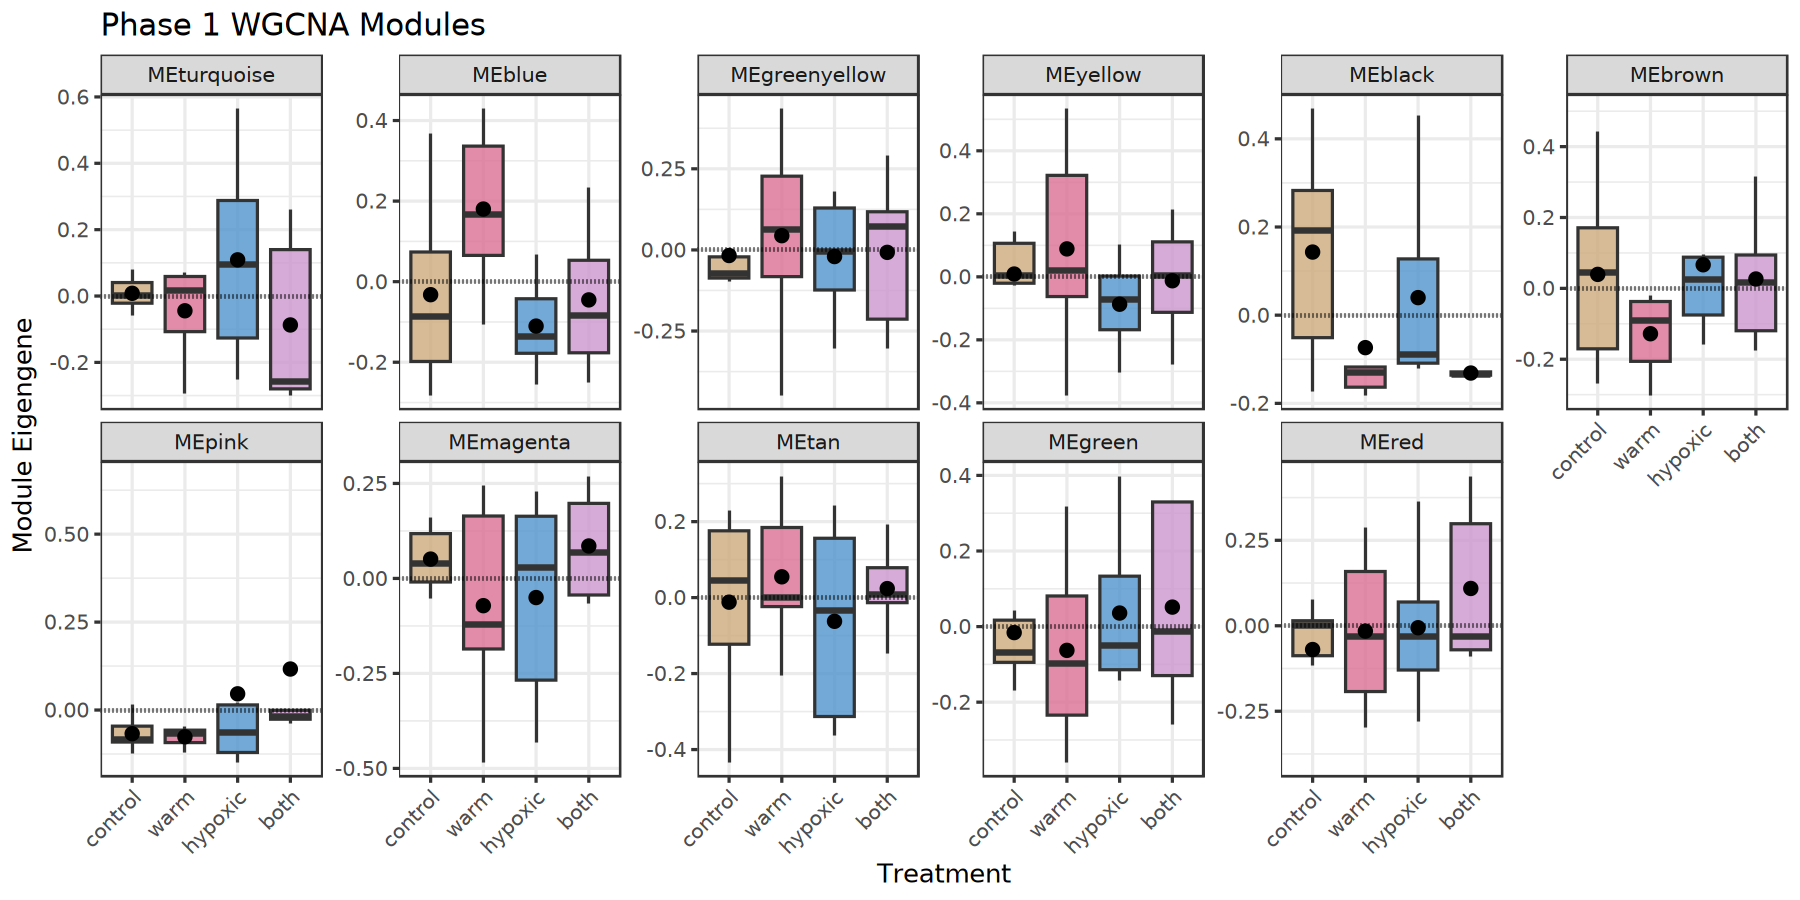

In [62]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

MEsPlotting_melt$Phase1_treatment <- factor(MEsPlotting_melt$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

MEs_boxplot <- ggplot(MEsPlotting_melt,
       aes(x = Phase1_treatment,
           y = Eigengene,
           fill = factor(Phase1_treatment))) +
  
  geom_boxplot(position = position_dodge(0.8),
               outlier.shape = NA,
               alpha = 0.8) +

scale_fill_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  
  stat_summary(fun = mean,
               geom = "point",
               color = "black",
               position = position_dodge(0.8),
               size = 3) +
  
  geom_hline(yintercept = 0,
             linetype = "dotted",
             linewidth = 1) +
  
  ylab("Module Eigengene") +
  theme_bw(base_size=15) +
  facet_wrap(~ Module, 
             scales = "free_y",
            nrow = 2) +
guides(fill = 'none') +
theme(
  axis.text.x = element_text(
    angle = 45,
    hjust = 1
  )
) +
labs(x = 'Treatment',
    title = 'Phase 1 WGCNA Modules')

MEs_boxplot

## 4. Identify hub genes
hub genes = gene with the most connectivity within its module 

In [63]:
hubGenes <- chooseTopHubInEachModule(dataExpr, # vst expr. matrix
                         mergedColors_sign, # from dendogram above
                         omitColors = "grey", # grey module = genes not assigned to any module
                         power = 5, 
                         type = "signed")

# make into df, assign modules in column
hubGenes.df <- as.data.frame(hubGenes) %>%
mutate(module = rownames(.))
# remove row names
rownames(hubGenes.df) <- NULL

hubGenes.df

hubGenes,module
<chr>,<chr>
LOC111137329,black
LOC111118049,blue
LOC111117922,brown
LOC111126798,green
LOC111132762,greenyellow
LOC111135396,magenta
LOC111103657,pink
LOC111135053,red
LOC111125835,tan


## 5. Gene significance (GS) and module membership (MM)
both are critical metrics for identifying hub genes within modules that are associated with specific treatment/traits
- GS = correlates gene expression with treatment/trait
- MM = how well a gene belongs to a module

basically select a module of interest and validate with GS and MM - combine GS and MM to find genes that are highly connected *and* strongly associated with the treatment/trait

In [64]:
modNames <- substring(names(MEs), 3)
modNames

[1] "turquoise"   "blue"        "greenyellow" "yellow"      "black"      
 [6] "brown"       "pink"        "magenta"     "tan"         "green"      
[11] "red"

#### module membership
MM is the same across all treatments

In [65]:
geneModuleMembership = as.data.frame(cor(dataExpr, MEs, use = "p"))
MMPvalue = as.data.frame(corPvalueStudent(as.matrix(geneModuleMembership), nSamples))

names(geneModuleMembership) = paste("MM", modNames, sep="")
names(MMPvalue) = paste("p.MM", modNames, sep="")

In [66]:
head(geneModuleMembership)

,MMturquoise,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621269,0.89861408,-0.02189933,0.2553021,-0.195497792,0.05614090,-0.07783847,0.02387075,-0.5982263,-0.35773894,-0.29604727,-0.3302351
LOC111120925,0.22364894,-0.33011009,0.1824377,-0.222540221,0.93062335,0.47319205,-0.17955367,-0.3722173,-0.57274446,-0.05904989,-0.4184101
LOC144621276,0.32555283,0.10542919,0.8336396,0.433549068,0.10024834,-0.07262645,0.18673517,-0.4212207,-0.35332463,-0.61945037,-0.7471177
LOC111115920,-0.37508082,0.14363768,-0.2462625,0.103735596,-0.47523803,-0.27407971,0.14502208,0.4534948,0.53821747,0.15788780,0.5751459
LOC144621308,0.05164062,0.19428139,0.2073378,0.005749374,-0.01013491,0.04988539,-0.13331337,-0.3945564,-0.29434882,-0.06321750,-0.2181847
LOC111112629,-0.03537683,0.16726564,0.4196162,0.343292221,0.01159283,-0.17506832,0.23523530,-0.1409036,0.01965665,-0.38558106,-0.2095978


#### gene significance
calculated for each treatment combination

In [67]:
##### GS #####
# calc GS for every gene and trait
geneTraitSignificance_df <- as.data.frame(
  cor(
    dataExpr,
    metaData_merge,
    use = "p"
  )
)

# add prefix to column names
colnames(geneTraitSignificance_df) <- paste0(
  "GS.",
  colnames(geneTraitSignificance_df)
)

##### PVAL #####
# calc pvalue
GSPvalue_df <- as.data.frame(
  corPvalueStudent(
    as.matrix(geneTraitSignificance_df),
    nSamples = nrow(dataExpr)
  )
)

# add prefix to column names
colnames(GSPvalue_df) <- paste0(
  "p.GS.",
  colnames(GSPvalue_df)
)

# check it out
head(geneTraitSignificance_df)
head(GSPvalue_df)

,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,GS.control,GS.hypoxic,GS.warm
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621269,0.27336164,0.3586458,0.2901469,-0.16210113,-0.22732900,-0.06424438,-0.27258024,0.07564726,0.18296060,-0.00256331
LOC111120925,-0.03486386,-0.1014883,-0.1725794,-0.39769221,-0.53212376,-0.17041242,-0.35206608,0.46849169,0.13684853,-0.27463172
LOC144621276,0.32875080,0.3864687,0.2500537,0.08261693,0.10598210,0.03768251,-0.01248221,-0.17515683,0.05459234,0.13228948
LOC111115920,-0.18340556,-0.4557764,-0.4584799,0.51564189,0.30405906,0.41389666,0.63636050,-0.21898473,-0.12691070,-0.25186118
LOC144621308,0.08088284,0.1530321,0.1019744,-0.04779239,-0.02842706,-0.03823947,-0.17146942,-0.08522810,0.11756652,0.12872905
LOC111112629,0.16910715,0.1166608,0.0154403,0.28660891,0.16911962,0.22999859,0.09065637,-0.36887722,0.17648793,0.10723245


,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.Actual_tissue_growth_mg,p.GS.GS.Ratio_tissue_shell_mg,p.GS.GS.P1_trtmt_code,p.GS.GS.P1_temp_code,p.GS.GS.P1_DO_code,p.GS.GS.both,p.GS.GS.control,p.GS.GS.hypoxic,p.GS.GS.warm
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621269,0.2069156,0.09285494,0.17927178,0.45992823,0.29686936,0.77087995,0.208268489,0.73155934,0.4033781,0.9907387
LOC111120925,0.8745163,0.64496284,0.43102358,0.06020792,0.00895885,0.43691967,0.099449166,0.02414795,0.5335190,0.2047292
LOC144621276,0.1256098,0.06851533,0.24984073,0.70783675,0.63031249,0.86445887,0.954922627,0.42406651,0.8045992,0.5473659
LOC111115920,0.4022156,0.02883871,0.02778516,0.01178964,0.15837632,0.04960499,0.001096996,0.31542663,0.5639111,0.2463206
LOC144621308,0.7137155,0.48573293,0.64337190,0.82856247,0.89755214,0.86247387,0.434038304,0.69901501,0.5931719,0.5582929
LOC111112629,0.4404919,0.59604184,0.94425456,0.18487477,0.44045767,0.29107834,0.680796970,0.08325462,0.4204976,0.6262597


In [68]:
colnames(geneTraitSignificance_df)

[1] "GS.Actual_shell_growth_mg"  "GS.Actual_tissue_growth_mg"
 [3] "GS.Ratio_tissue_shell_mg"   "GS.P1_trtmt_code"          
 [5] "GS.P1_temp_code"            "GS.P1_DO_code"             
 [7] "GS.both"                    "GS.control"                
 [9] "GS.hypoxic"                 "GS.warm"

In [69]:
annot <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
colnames(annot)[1] <- 'Gene'
colnames(annot)[2] <- 'GO.terms'
head(annot)

,Gene,GO.terms
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


In [70]:
# 1. Create a data frame for gene information
# Ensure the names of the vector match your gene names
gene_info <- data.frame(
  Gene = colnames(dataExpr),
  ModuleColor = mergedColors_sign
)

# 2. Bind it with  MM and GS dataframes
# (Assuming these have genes as row names in the same order)
final_results <- cbind(gene_info, geneTraitSignificance_df, GSPvalue_df, geneModuleMembership)

# 3. Add GO terms
final_res <- merge(annot, final_results, by = 'Gene')

# 3. Take a look
head(final_res)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.282186775,0.06994163,0.1492213,0.385003047,-0.02872849,0.12634487,⋯,0.3336787,0.09526861,-0.03750345,-0.01178295,-0.04856269,0.115416013,-0.46324802,-0.19648759,0.05033161,-0.04085780
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,black,-0.02461599,0.002751307,-0.03894892,-0.4217885,-0.363072643,-0.28138410,-0.24659525,⋯,-0.2452065,-0.14257739,-0.16774119,0.34293007,0.31439017,-0.065239565,0.07719106,-0.15380042,0.22565913,0.02356195
3,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.303838275,-0.01706141,-0.2141764,0.221972568,-0.34604876,-0.04315846,⋯,0.1248501,0.26055230,0.01693705,0.20241978,0.34095291,0.002859469,-0.37935688,-0.49934818,0.05801009,-0.35374473
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.41098524,-0.310348052,-0.04403876,0.3171945,0.004370064,0.34594159,0.31502257,⋯,-0.4530072,-0.51091263,-0.31182848,-0.07876548,0.07063991,0.365824475,0.50638260,0.32368892,0.40288267,0.68022795
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,green,-0.35176148,-0.282846525,-0.03894228,-0.0592647,-0.254057873,0.06198487,-0.01882029,⋯,-0.3888532,-0.68292735,-0.49529157,0.14867298,0.47087567,-0.253669949,0.40577513,0.03737518,0.72387889,0.49103455
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.181368789,-0.15299170,-0.3250255,0.370840965,-0.54214175,-0.10090793,⋯,0.7387194,0.17197754,0.25907960,0.07602426,-0.20551234,-0.602026100,-0.33485347,-0.05929480,-0.20905792,-0.29068175


In [71]:
#write.csv(final_res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_GeneInfo.csv', row.names = FALSE)